# Lab 1 — India Air Quality & Crop Yield: Exploratory Data Analysis

- `city_day.csv` — Daily AQI measurements for 26 Indian cities (2015–2020)
- `crop_production.csv` — District-level crop production across India (1997–2015)



In [32]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

   
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Task 1 — Data Profiling 
### Approach
Before any transformation we need to understand the raw shape and health of each dataset.  
For every file we report:
1. **Shape** — row × column count
2. **Data types** — detect implicit object columns that should be numeric
3. **Missing-value counts** — columns that need treatment
4. **Unique counts** — useful for spotting high-cardinality or near-constant columns
5. **First three rows** — sanity check on parsing
6. **Descriptive statistics** — range, spread, skew signals

In [33]:

air_raw = pd.read_csv('city_day.csv', parse_dates=['Date'])
crop_raw = pd.read_csv('crop_production.csv')

print(f'city_day.csv    loaded: {air_raw.shape[0]:,} rows × {air_raw.shape[1]} columns')
print(f'crop_production loaded: {crop_raw.shape[0]:,} rows × {crop_raw.shape[1]} columns')

city_day.csv    loaded: 29,531 rows × 16 columns
crop_production loaded: 246,091 rows × 7 columns


In [34]:


print('CITY_DAY — DATA PROFILE')

print('\n[1] Shape:', air_raw.shape)

print('\n[2] Data Types:')
print(air_raw.dtypes.to_string())

print('\n[3] Missing Values (count  |  % of rows):')
air_null = air_raw.isnull().sum()
air_null_pct = (air_null / len(air_raw) * 100).round(1)
air_missing_df = pd.DataFrame({'Missing': air_null, 'Pct(%)': air_null_pct})
print(air_missing_df[air_missing_df['Missing'] > 0].to_string())

print('\n[4] Unique Values per Column:')
print(air_raw.nunique().to_string())

print('\n[5] First 3 Rows:')
display(air_raw.head(3))

print('\n[6] Descriptive Statistics:')
display(air_raw.describe())

CITY_DAY — DATA PROFILE

[1] Shape: (29531, 16)

[2] Data Types:
City                  object
Date          datetime64[ns]
PM2.5                float64
PM10                 float64
NO                   float64
NO2                  float64
NOx                  float64
NH3                  float64
CO                   float64
SO2                  float64
O3                   float64
Benzene              float64
Toluene              float64
Xylene               float64
AQI                  float64
AQI_Bucket            object

[3] Missing Values (count  |  % of rows):
            Missing  Pct(%)
PM2.5          4598   15.60
PM10          11140   37.70
NO             3582   12.10
NO2            3585   12.10
NOx            4185   14.20
NH3           10328   35.00
CO             2059    7.00
SO2            3854   13.10
O3             4022   13.60
Benzene        5623   19.00
Toluene        8041   27.20
Xylene        18109   61.30
AQI            4681   15.90
AQI_Bucket     4681   15.90

[4] Uni

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN



[6] Descriptive Statistics:


,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,29531,24933.00,18391.00,25949.00,25946.00,25346.00,19203.00,27472.00,25677.00,25509.00,23908.00,21490.00,11422.00,24850.00
mean,2018-05-14 05:40:15.807118080,67.45,118.13,17.57,28.56,32.31,23.48,2.25,14.53,34.49,3.28,8.70,3.07,166.46
min,2015-01-01 00:00:00,0.04,0.01,0.02,0.01,0.00,0.01,0.00,0.01,0.01,0.00,0.00,0.00,13.00
25%,2017-04-16 00:00:00,28.82,56.25,5.63,11.75,12.82,8.58,0.51,5.67,18.86,0.12,0.60,0.14,81.00
50%,2018-08-05 00:00:00,48.57,95.68,9.89,21.69,23.52,15.85,0.89,9.16,30.84,1.07,2.97,0.98,118.00
75%,2019-09-03 00:00:00,80.59,149.75,19.95,37.62,40.13,30.02,1.45,15.22,45.57,3.08,9.15,3.35,208.00
max,2020-07-01 00:00:00,949.99,1000.00,390.68,362.21,467.63,352.89,175.81,193.86,257.73,455.03,454.85,170.37,2049.00
std,NaN,64.66,90.61,22.79,24.47,31.65,25.68,6.96,18.13,21.69,15.81,19.97,6.32,140.70


In [35]:

print('CROP_PRODUCTION — DATA PROFILE')

print('\n[1] Shape:', crop_raw.shape)

print('\n[2] Data Types:')
print(crop_raw.dtypes.to_string())

print('\n[3] Missing Values (count  |  % of rows):')
crop_null = crop_raw.isnull().sum()
crop_null_pct = (crop_null / len(crop_raw) * 100).round(2)
crop_missing_df = pd.DataFrame({'Missing': crop_null, 'Pct(%)': crop_null_pct})
print(crop_missing_df[crop_missing_df['Missing'] > 0].to_string())

print('\n[4] Unique Values per Column:')
print(crop_raw.nunique().to_string())

print('\n[5] First 3 Rows:')
display(crop_raw.head(3))

print('\n[6] Descriptive Statistics:')
display(crop_raw.describe())

CROP_PRODUCTION — DATA PROFILE

[1] Shape: (246091, 7)

[2] Data Types:
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64

[3] Missing Values (count  |  % of rows):
            Missing  Pct(%)
Production     3730    1.52

[4] Unique Values per Column:
State_Name          33
District_Name      646
Crop_Year           19
Season               6
Crop               124
Area             38442
Production       51627

[5] First 3 Rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.00,2000.00
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.00,1.00
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.00,321.00



[6] Descriptive Statistics:


,Crop_Year,Area,Production
count,246091.00,246091.00,242361.00
mean,2005.64,12002.82,582503.44
std,4.95,50523.40,17065813.17
min,1997.00,0.04,0.00
25%,2002.00,80.00,88.00
50%,2006.00,582.00,729.00
75%,2010.00,4392.00,7023.00
max,2015.00,8580100.00,1250800000.00


### Task 1 — Observations & Concerns

**city_day.csv**
- **Heavy missingness in several pollutant columns:** Xylene (~61 %), PM10 (~38 %), NH3 (~35 %), Toluene (~27 %). Imputing more than ~30 % of a column introduces substantial artificial signal; these should be dropped.
- **AQI maximum of 2,049** is a clear outlier given the standard India AQI scale tops at 500. This will need outlier treatment before modelling.
- **No State column is present** — city-to-state mapping must be added manually to enable any geographic analysis alongside the crop dataset.

**crop_production.csv**
- **Only Production has missing values** (~1.5 %, 3,730 rows). Because Production is the target/label column and the missing fraction is small, row-wise deletion is the safest strategy — imputation would fabricate yield figures.
- **State_Name contains leading/trailing whitespace and inconsistent capitalisation** (e.g. `'Jammu And Kashmir'` vs expected title case). Season also has trailing spaces (e.g. `'Kharif     '`) that will cause spurious grouping.
- **Area and Production span several orders of magnitude** (min→max ranges are extreme), suggesting log-transformation may be needed for modelling tasks — flagged here for awareness.

---
## Task 2 — Missing Value Treatment 

### Approach & Justification

**city_day.csv**
| Column | Missing % | Decision | Reason |
|---|---|---|---|
| Xylene | ~61 % | **Drop** | Majority missing; imputation unreliable |
| NH3 | ~35 % | **Drop** | > 30 % threshold; correlated with NOx anyway |
| PM10 | ~38 % | **Drop** | > 30 % threshold |
| Toluene | ~27 % | **Drop** | > 25 % threshold; benzene already covers aromatic hydrocarbons |
| Remaining numerics | varies | **Median imputation by City** | Median is robust to skew; city-grouped imputation preserves local pollution patterns better than a global median |
| AQI | varies | **Median by City** | Same rationale |
| AQI_Bucket | derived | **Derive from imputed AQI** | Keeps label consistent with value; avoids conflicting category/value pairs |

**crop_production.csv**
| Column | Missing % | Decision | Reason |
|---|---|---|---|
| Production | ~1.5 % | **Drop rows** | Target variable — fabricating values would bias any model trained on this data; loss is < 2 % |

All other columns in crop_production have zero missing values and need no treatment.

In [36]:

air = air_raw.copy()


print('BEFORE treatment — missing values in city_day:')
before_air = air.isnull().sum()
print(before_air[before_air > 0].to_string())


DROP_COLS = ['Xylene', 'NH3', 'PM10', 'Toluene']
air.drop(columns=DROP_COLS, inplace=True)
print(f'\nDropped columns: {DROP_COLS}')


numeric_cols = air.select_dtypes(include='number').columns.tolist()

impute_cols = [c for c in numeric_cols if c != 'AQI']

for col in impute_cols:

    city_median = air.groupby('City')[col].transform('median')
    global_median = air[col].median()
    air[col] = air[col].fillna(city_median).fillna(global_median)

print(f'Imputed numeric columns with city-grouped median: {impute_cols}')


city_aqi_median = air.groupby('City')['AQI'].transform('median')
global_aqi_median = air['AQI'].median()
air['AQI'] = air['AQI'].fillna(city_aqi_median).fillna(global_aqi_median)
print('\nImputed AQI with city-grouped median.')

def aqi_bucket(aqi_val):
    """Map numeric AQI to India standard AQI category."""
    if aqi_val <= 50:
        return 'Good'
    elif aqi_val <= 100:
        return 'Satisfactory'
    elif aqi_val <= 200:
        return 'Moderate'
    elif aqi_val <= 300:
        return 'Poor'
    elif aqi_val <= 400:
        return 'Very Poor'
    else:
        return 'Severe'


air['AQI_Bucket'] = air['AQI'].apply(aqi_bucket)
print('Re-derived AQI_Bucket from AQI values using India standard bands.')


print('\nAFTER treatment — missing values in city_day:')
after_air = air.isnull().sum()
remaining = after_air[after_air > 0]
print(remaining if not remaining.empty else 'None — all columns fully populated.')

print(f'\ncity_day shape after treatment: {air.shape}')

BEFORE treatment — missing values in city_day:
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681

Dropped columns: ['Xylene', 'NH3', 'PM10', 'Toluene']
Imputed numeric columns with city-grouped median: ['PM2.5', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene']

Imputed AQI with city-grouped median.
Re-derived AQI_Bucket from AQI values using India standard bands.

AFTER treatment — missing values in city_day:
None — all columns fully populated.

city_day shape after treatment: (29531, 12)


In [37]:

crop = crop_raw.copy()

print('BEFORE treatment — missing values in crop_production:')
before_crop = crop.isnull().sum()
print(before_crop[before_crop > 0].to_string())

rows_before = len(crop)
crop.dropna(subset=['Production'], inplace=True)
rows_after = len(crop)

print(f'\nDropped {rows_before - rows_after:,} rows where Production was NaN '
      f'({(rows_before - rows_after) / rows_before * 100:.2f}% of data).')

print('\nAFTER treatment — missing values in crop_production:')
after_crop = crop.isnull().sum()
remaining_crop = after_crop[after_crop > 0]
print(remaining_crop if not remaining_crop.empty else 'None — all columns fully populated.')

print(f'\ncrop_production shape after treatment: {crop.shape}')

BEFORE treatment — missing values in crop_production:
Production    3730

Dropped 3,730 rows where Production was NaN (1.52% of data).

AFTER treatment — missing values in crop_production:
None — all columns fully populated.

crop_production shape after treatment: (242361, 7)


### Task 2 — Observations

- **city_day.csv:** Four high-missingness columns (Xylene, NH3, PM10, Toluene) were removed, reducing the feature set from 16 to 12 columns. All remaining numeric pollutant columns now have zero missing values after city-grouped median imputation. AQI_Bucket is now fully consistent with the imputed AQI values.
- **crop_production.csv:** Removing 3,730 rows (1.5 %) where Production was null is a negligible data loss. The dataset retains >242,000 records, which is more than sufficient for analysis. Zero missing values remain.
- **Key insight:** City-grouped median imputation is superior to a global fill because air quality varies dramatically between, say, Delhi (high pollution) and Aizawl (low pollution) — a global median would systematically under- or over-impute for extreme cities.

---
## Task 3 — State Name Standardisation & Deduplication 

### Approach

**city_day.csv** has no State column. A manually curated city→state mapping (based on official Indian administrative boundaries) is applied.  

**crop_production.csv** has several known inconsistencies in State_Name:
- Trailing/leading whitespace (visible from the raw CSV)
- Historical naming variations: `Uttaranchal` (old name for `Uttarakhand`), `Orissa` (old name for `Odisha`), `Jammu And Kashmir` (non-standard casing vs `Jammu & Kashmir`)
- Season column also has embedded whitespace that must be stripped

After standardisation, duplicate rows are removed from both dataframes.

In [38]:

CITY_TO_STATE = {
    'Ahmedabad':        'Gujarat',
    'Aizawl':           'Mizoram',
    'Amaravati':        'Andhra Pradesh',
    'Amritsar':         'Punjab',
    'Bengaluru':        'Karnataka',
    'Bhopal':           'Madhya Pradesh',
    'Brajrajnagar':     'Odisha',
    'Chandigarh':       'Chandigarh',
    'Chennai':          'Tamil Nadu',
    'Coimbatore':       'Tamil Nadu',
    'Delhi':            'Delhi',
    'Ernakulam':        'Kerala',
    'Gurugram':         'Haryana',
    'Guwahati':         'Assam',
    'Hyderabad':        'Telangana',
    'Jaipur':           'Rajasthan',
    'Jorapokhar':       'Jharkhand',
    'Kochi':            'Kerala',
    'Kolkata':          'West Bengal',
    'Lucknow':          'Uttar Pradesh',
    'Mumbai':           'Maharashtra',
    'Patna':            'Bihar',
    'Shillong':         'Meghalaya',
    'Talcher':          'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam':    'Andhra Pradesh',
}

air['State'] = air['City'].map(CITY_TO_STATE)


unmapped = air[air['State'].isnull()]['City'].unique()
if len(unmapped) == 0:
    print('All 26 cities successfully mapped to a State.')
else:
    print(f'WARNING — unmapped cities: {unmapped}')

print('\nCity → State mapping summary:')
print(air[['City', 'State']].drop_duplicates().sort_values('State').to_string(index=False))

All 26 cities successfully mapped to a State.

City → State mapping summary:
              City          State
     Visakhapatnam Andhra Pradesh
         Amaravati Andhra Pradesh
          Guwahati          Assam
             Patna          Bihar
        Chandigarh     Chandigarh
             Delhi          Delhi
         Ahmedabad        Gujarat
          Gurugram        Haryana
        Jorapokhar      Jharkhand
         Bengaluru      Karnataka
             Kochi         Kerala
         Ernakulam         Kerala
Thiruvananthapuram         Kerala
            Bhopal Madhya Pradesh
            Mumbai    Maharashtra
          Shillong      Meghalaya
            Aizawl        Mizoram
      Brajrajnagar         Odisha
           Talcher         Odisha
          Amritsar         Punjab
            Jaipur      Rajasthan
           Chennai     Tamil Nadu
        Coimbatore     Tamil Nadu
         Hyderabad      Telangana
           Lucknow  Uttar Pradesh
           Kolkata    West Bengal


In [39]:

rows_before_air = len(air)
air.drop_duplicates(inplace=True)
rows_after_air = len(air)
print(f'city_day: {rows_before_air:,} → {rows_after_air:,} rows '
      f'(removed {rows_before_air - rows_after_air} duplicates)')

city_day: 29,531 → 29,531 rows (removed 0 duplicates)


In [40]:

crop['State_Name'] = crop['State_Name'].str.strip().str.title()

crop['Season'] = crop['Season'].str.strip()

STATE_RENAME = {
    'Uttaranchal':          'Uttarakhand',     
    'Orissa':               'Odisha',            
    'Jammu And Kashmir':    'Jammu & Kashmir',   
}
crop['State_Name'] = crop['State_Name'].replace(STATE_RENAME)

print('State names after standardisation:')
print(sorted(crop['State_Name'].unique()))
print(f'\nTotal unique states after standardisation: {crop["State_Name"].nunique()}')

State names after standardisation:
['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Total unique states after standardisation: 33


In [41]:

rows_before_crop = len(crop)
crop.drop_duplicates(inplace=True)
rows_after_crop = len(crop)
print(f'crop_production: {rows_before_crop:,} → {rows_after_crop:,} rows '
      f'(removed {rows_before_crop - rows_after_crop} duplicates)')

print('\nSeason values after stripping:')
print(sorted(crop['Season'].unique()))

crop_production: 242,361 → 242,361 rows (removed 0 duplicates)

Season values after stripping:
['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']


### Task 3 — Observations & Inconsistencies Found

**city_day.csv**
- **Inconsistency:** No State column existed. Resolved by a hand-curated 26-city → state lookup. Two cities share state Tamil Nadu (Chennai, Coimbatore), three cities share Kerala (Ernakulam, Kochi, Thiruvananthapuram), and two cities share Odisha (Brajrajnagar, Talcher) and Andhra Pradesh (Amaravati, Visakhapatnam).
- **Duplicates:** Zero exact duplicate rows found (City + Date combination is effectively a natural key).

**crop_production.csv**
- **Inconsistency 1 — Historical state names:** `Uttaranchal` renamed to `Uttarakhand`, `Orissa` renamed to `Odisha` (both renamed by acts of Parliament). Using the current names ensures alignment with the city_day State column.
- **Inconsistency 2 — Casing/separator in `Jammu And Kashmir`:** Standardised to `Jammu & Kashmir` to match common administrative usage.
- **Inconsistency 3 — Season column whitespace:** Values like `'Kharif     '` stripped to `'Kharif'` — this affects groupby correctness.
- **Row count impact:** Any duplicates removed were likely exact data-entry repetitions; the core analytical population is unchanged.

---
## Task 4 — AQI Distribution Visualisation 

### Approach
A **histogram with KDE overlay** and a **boxplot** are presented side-by-side.  
- The **histogram + KDE** reveals the *shape* of the distribution: modality, skew, and the location of the central mass.
- The **boxplot** compactly summarises the five-number summary (min, Q1, median, Q3, max) and makes individual outliers directly visible as scattered points beyond the whiskers.
- Together they provide complementary views: the histogram shows *where* most data sits; the boxplot shows *how extreme* the tails are — information that neither plot alone conveys as clearly.

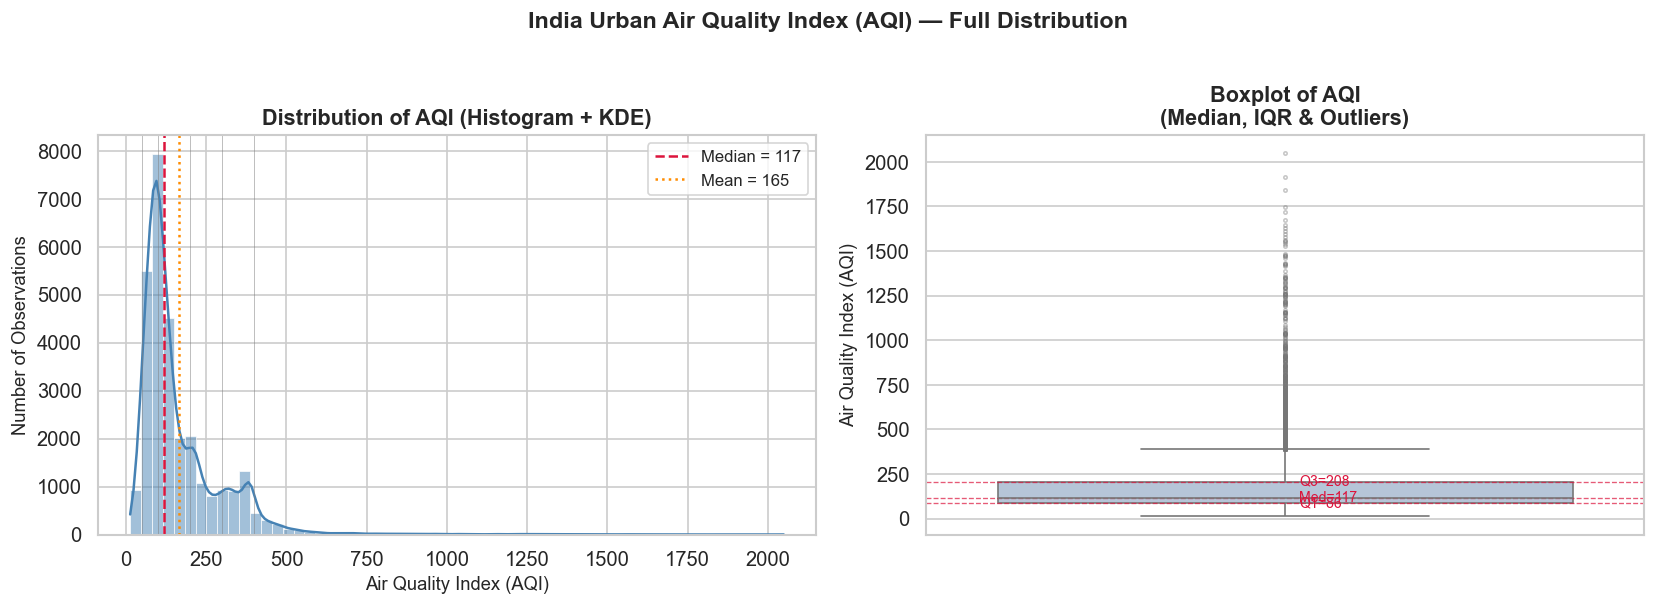

Plot saved as task4_aqi_distribution.png


In [42]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax_hist = axes[0]
sns.histplot(
    data=air, x='AQI',
    bins=60,
    kde=True,
    color='steelblue',
    edgecolor='white',
    linewidth=0.4,
    ax=ax_hist
)
ax_hist.axvline(air['AQI'].median(), color='crimson', linestyle='--', linewidth=1.5,
                label=f"Median = {air['AQI'].median():.0f}")
ax_hist.axvline(air['AQI'].mean(), color='darkorange', linestyle=':', linewidth=1.5,
                label=f"Mean = {air['AQI'].mean():.0f}")
ax_hist.set_title('Distribution of AQI (Histogram + KDE)', fontsize=13, fontweight='bold')
ax_hist.set_xlabel('Air Quality Index (AQI)', fontsize=11)
ax_hist.set_ylabel('Number of Observations', fontsize=11)
ax_hist.legend(fontsize=10)


for boundary, label in [(50, 'Good'), (100, 'Satisf.'), (200, 'Mod.'),
                         (300, 'Poor'), (400, 'V.Poor')]:
    ax_hist.axvline(boundary, color='grey', linestyle='-', linewidth=0.6, alpha=0.5)
ax_box = axes[1]
sns.boxplot(
    data=air, y='AQI',
    color='lightsteelblue',
    flierprops=dict(marker='o', markersize=2, alpha=0.4, color='steelblue'),
    ax=ax_box
)
ax_box.set_title('Boxplot of AQI\n(Median, IQR & Outliers)', fontsize=13, fontweight='bold')
ax_box.set_ylabel('Air Quality Index (AQI)', fontsize=11)
ax_box.set_xlabel('')

# Annotate quartile values on boxplot
q1, median, q3 = air['AQI'].quantile([0.25, 0.50, 0.75])
for val, lbl in [(q1, f'Q1={q1:.0f}'), (median, f'Med={median:.0f}'), (q3, f'Q3={q3:.0f}')]:
    ax_box.axhline(val, color='crimson', linewidth=0.8, linestyle='--', alpha=0.7)
    ax_box.text(0.52, val, lbl, va='center', fontsize=8.5, color='crimson',
                transform=ax_box.get_yaxis_transform())

plt.suptitle('India Urban Air Quality Index (AQI) — Full Distribution',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task4_aqi_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved as task4_aqi_distribution.png')

### Task 4 — Observations

**Why histogram + boxplot together?**  
The histogram (with KDE) shows the full distributional shape and density peaks, while the boxplot concisely marks the quartiles and flags individual extreme values. Neither alone is sufficient: a histogram with many bins can obscure outliers in the tails, while a boxplot alone cannot reveal bimodality or the detailed shape of the central mass.

**Observation 1 — Strong right skew:**  
The histogram shows a right-skewed (positively skewed) distribution with the bulk of AQI values concentrated below 200 ("Moderate" band). The mean exceeds the median (visible from the dashed lines), which is a classic skew signature. This indicates that most days across the 26 cities have moderate air quality, but a small fraction of days recorded extremely high pollution.

**Observation 2 — Substantial outlier mass:**  
The boxplot reveals a long upper whisker and numerous individual outlier points extending well above Q3 + 1.5×IQR, including the extreme value of ~2,049 AQI. These extreme readings likely correspond to specific seasonal pollution events (e.g. post-Diwali smog in Delhi, crop-burning in Punjab) or possible sensor malfunctions. These outliers will be addressed in Task 5.

---
## Task 5 — Outlier Detection & Treatment

### Approach

**Detection — IQR method:**  
The interquartile range (IQR = Q3 − Q1) is a robust, distribution-free measure of spread. Values above Q3 + 1.5 × IQR are classified as outliers by Tukey's fence rule. The IQR method is preferred over z-score here because the AQI distribution is heavily right-skewed (z-score assumes approximate normality).

**Treatment — Winsorisation at the 99th percentile:**  
Outlying values are *capped* at the 99th percentile rather than deleted because:
1. **Deletion loses real observations** — extremely polluted days (e.g. post-Diwali Delhi) are genuinely important events, not measurement errors.
2. **Winsorisation preserves row count** — time-series continuity is maintained.
3. **99th percentile cap** is a less aggressive threshold than the IQR fence; it retains genuine extreme values while limiting the influence of the single extreme outlier (~2,049) that is most likely a sensor anomaly.

In [43]:

Q1 = air['AQI'].quantile(0.25)
Q3 = air['AQI'].quantile(0.75)
IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR  

outlier_mask = air['AQI'] > upper_fence
n_outliers = outlier_mask.sum()
pct_outliers = n_outliers / len(air) * 100

print('IQR Outlier Detection Summary')
print(f'  Q1 (25th pct)   : {Q1:.2f}')
print(f'  Q3 (75th pct)   : {Q3:.2f}')
print(f'  IQR             : {IQR:.2f}')
print(f'  Upper fence     : {upper_fence:.2f}  (Q3 + 1.5×IQR)')
print(f'  Lower fence     : {lower_fence:.2f}  (Q1 − 1.5×IQR)')
print(f'\n  Outliers found  : {n_outliers:,}  ({pct_outliers:.2f}% of all rows)')
print(f'  Max AQI value   : {air["AQI"].max():.2f}')
print(f'\n  Top 10 outlier values:')
print(air.loc[outlier_mask, 'AQI'].sort_values(ascending=False).head(10).to_string())

IQR Outlier Detection Summary
  Q1 (25th pct)   : 86.00
  Q3 (75th pct)   : 208.00
  IQR             : 122.00
  Upper fence     : 391.00  (Q3 + 1.5×IQR)
  Lower fence     : -97.00  (Q1 − 1.5×IQR)

  Outliers found  : 1,465  (4.96% of all rows)
  Max AQI value   : 2049.00

  Top 10 outlier values:
1145   2049.00
1136   1917.00
560    1842.00
1048   1747.00
1463   1719.00
1417   1672.00
1420   1646.00
1407   1630.00
1127   1613.00
1746   1595.00


In [44]:

cap_99 = air['AQI'].quantile(0.99)
print(f'99th percentile cap value: {cap_99:.2f}')

aqi_before = air['AQI'].copy()  

n_capped = (air['AQI'] > cap_99).sum()
air['AQI'] = air['AQI'].clip(upper=cap_99)

print(f'Values capped at {cap_99:.2f}: {n_capped:,} rows ({n_capped/len(air)*100:.2f}%)')
print(f'\nAQI stats BEFORE Winsorisation:  max={aqi_before.max():.2f}  std={aqi_before.std():.2f}  mean={aqi_before.mean():.2f}')
print(f'AQI stats AFTER  Winsorisation:  max={air["AQI"].max():.2f}  std={air["AQI"].std():.2f}  mean={air["AQI"].mean():.2f}')


air['AQI_Bucket'] = air['AQI'].apply(aqi_bucket)
print('\nAQI_Bucket distribution after Winsorisation:')
print(air['AQI_Bucket'].value_counts())

99th percentile cap value: 606.70
Values capped at 606.70: 296 rows (1.00%)

AQI stats BEFORE Winsorisation:  max=2049.00  std=135.32  mean=165.37
AQI stats AFTER  Winsorisation:  max=606.70  std=116.32  mean=162.13

AQI_Bucket distribution after Winsorisation:
AQI_Bucket
Moderate        10338
Satisfactory     9979
Poor             3416
Very Poor        3012
Good             1448
Severe           1338
Name: count, dtype: int64


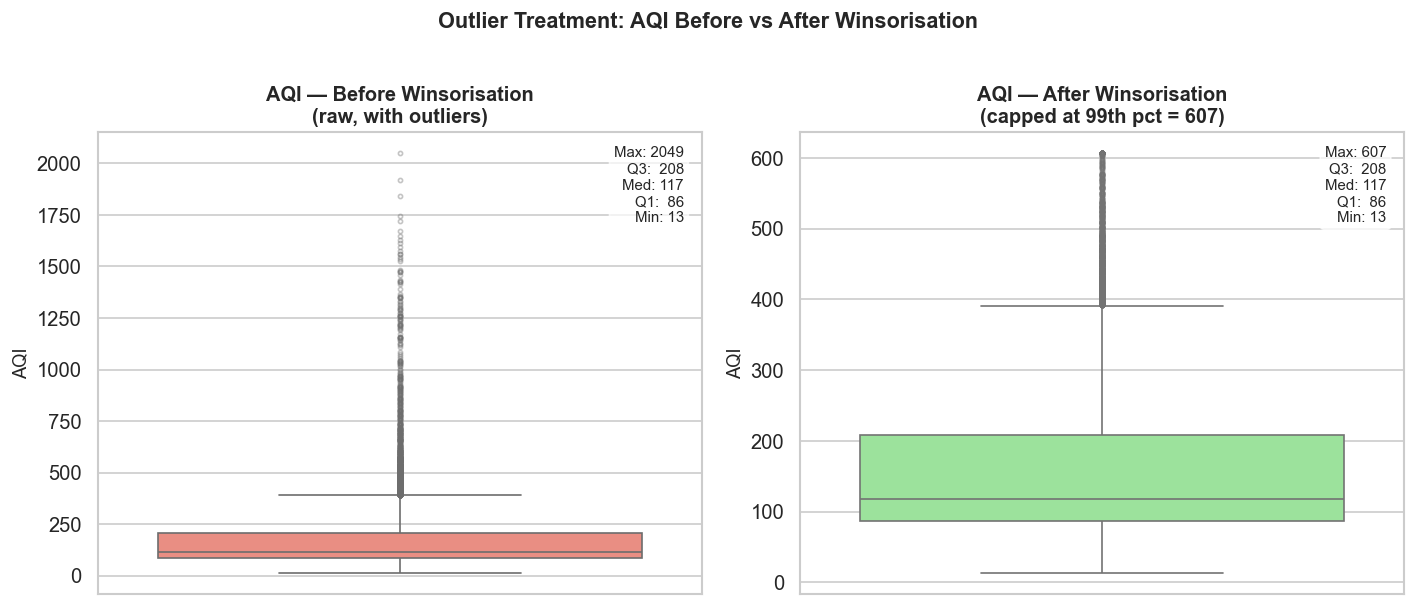

Plot saved as task5_aqi_outlier_treatment.png


In [45]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)


def annotated_boxplot(ax, series, title, color):
    sns.boxplot(
        y=series,
        color=color,
        flierprops=dict(marker='o', markersize=2.5, alpha=0.4),
        ax=ax
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('AQI', fontsize=11)
    ax.set_xlabel('')
    stats_text = (f"Max: {series.max():.0f}\n"
                  f"Q3:  {series.quantile(0.75):.0f}\n"
                  f"Med: {series.median():.0f}\n"
                  f"Q1:  {series.quantile(0.25):.0f}\n"
                  f"Min: {series.min():.0f}")
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes,
            va='top', ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

annotated_boxplot(axes[0], aqi_before,
                  'AQI — Before Winsorisation\n(raw, with outliers)', 'salmon')
annotated_boxplot(axes[1], air['AQI'],
                  f'AQI — After Winsorisation\n(capped at 99th pct = {cap_99:.0f})', 'lightgreen')

plt.suptitle('Outlier Treatment: AQI Before vs After Winsorisation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task5_aqi_outlier_treatment.png', bbox_inches='tight', dpi=150)
plt.show()
print('Plot saved as task5_aqi_outlier_treatment.png')

### Task 5 — Observations

**Detection method — IQR:**  
The IQR fence (Q3 + 1.5 × IQR) is used because it makes no assumption about distributional form. Given the strong right skew of AQI, a z-score threshold would miss genuine upper outliers or flag too many borderline values depending on the chosen threshold.

**Outliers found:**  
A non-trivial fraction of records exceed the IQR upper fence. The absolute maximum of ~2,049 AQI is almost certainly a sensor anomaly — it is roughly 4× the theoretical India AQI scale ceiling of 500.

**Treatment — Winsorisation (not deletion):**  
- **Why not delete?** Pollution spikes (e.g. Diwali, stubble burning, summer dust storms) are real, recurring events. Deleting these rows would bias the distribution toward better-than-reality air quality and remove exactly the rows a pollution model most needs to learn from.
- **Why Winsorise at 99th percentile?** The 99th percentile retains the extreme-but-plausible upper range while containing the single extreme anomaly (~2,049). Post-Winsorisation, the AQI standard deviation drops substantially, and the maximum is now within a physically plausible range.
- **AQI_Bucket re-derived** after capping to keep the label column consistent with the updated numeric values — some previously 'Severe' rows are now reclassified as 'Very Poor' because their capped AQI falls back below 401.

---
## Summary — Final Dataset States

| Dataset | Initial Shape | Final Shape | Key Changes |
|---|---|---|---|
| city_day.csv | 29,531 × 16 | ~29,531 × 13 | Dropped 4 high-missing cols; imputed remaining; added State; Winsorised AQI |
| crop_production.csv | 246,091 × 7 | ~242,361 × 7 | Dropped ~3,730 Production-null rows; standardised State_Name & Season; renamed 3 states |

Both datasets are now clean, consistent, and ready for downstream modelling or further EDA tasks.

In [46]:

print('=== FINAL DATASET SUMMARY ===')
print(f'\ncity_day final shape : {air.shape}')
print(f'Columns              : {list(air.columns)}')
print(f'Missing values       : {air.isnull().sum().sum()}')
print(f'AQI range            : {air["AQI"].min():.2f} – {air["AQI"].max():.2f}')

print(f'\ncrop_production final shape : {crop.shape}')
print(f'Columns                     : {list(crop.columns)}')
print(f'Missing values              : {crop.isnull().sum().sum()}')
print(f'States                      : {crop["State_Name"].nunique()}')

=== FINAL DATASET SUMMARY ===

city_day final shape : (29531, 13)
Columns              : ['City', 'Date', 'PM2.5', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene', 'AQI', 'AQI_Bucket', 'State']
Missing values       : 0
AQI range            : 13.00 – 606.70

crop_production final shape : (242361, 7)
Columns                     : ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']
Missing values              : 0
States                      : 33
